# Inference Pipeline — Iranian ALPR / ANPR

This notebook integrates the three trained models:

- Model 1: Whole plate detector
- Model 2: Character detector on cropped plate images
- Model 3: Character classifier

Supported inputs:
- Single image
- Directory of images
- Video file

Main pipeline:
1. Detect plate regions in full image/frame.
2. Crop each detected plate.
3. Detect exactly 8 character boxes per plate.
4. Sort characters left-to-right.
5. Classify each character crop.
6. Validate Iranian plate format.
7. Aggregate confidence via geometric mean.
8. For video, track/deduplicate plates across frames.

## Inference Safety Contract

This notebook follows strict inference rules:

- No silent CPU fallback during model loading unless explicitly enabled.
- Image dimensions are read from actual image/frame arrays.
- Model 2 output must contain exactly 8 accepted character detections.
- Character detections are sorted left-to-right.
- Plate text must match configured plate format.
- Confidence is aggregated with geometric mean.
- Video OCR is deduplicated with IoU-based tracking.
- Low-confidence or invalid-format plates are marked, not silently accepted.
- All failures return structured rejection reasons.

In [1]:
from __future__ import annotations

import os
import cv2
import json
import math
import time
import random
import platform
import warnings
from pathlib import Path
from dataclasses import dataclass, asdict
from typing import Any, Dict, List, Tuple, Optional

from collections import Counter, defaultdict
from scipy.optimize import linear_sum_assignment

import numpy as np
import pandas as pd

from PIL import Image, ImageDraw, ImageFont, ImageFile

import arabic_reshaper
from bidi.algorithm import get_display

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.models import convnext_small

try:
    from ultralytics import YOLO
except Exception as exc:
    YOLO = None
    raise RuntimeError(
        "Could not import ultralytics. Install with: pip install ultralytics"
    ) from exc


ImageFile.LOAD_TRUNCATED_IMAGES = False
warnings.filterwarnings("default")

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Platform:", platform.platform())

Python: 3.10.19
PyTorch: 2.12.0
Platform: macOS-26.5.1-arm64-arm-64bit


In [2]:
@dataclass(frozen=True)
class InferenceConfig:
    project_root: Path = Path(".").resolve()

    # Model paths
    model1_weights: Path = Path("Saved models/model_1/train_run/weights/best.pt")
    model2_weights: Path = Path("Saved models/model_2/train_run/weights/best.pt")
    model3_weights: Path = Path("Saved models/model_3/best_model.pt")
    model3_class_map_path: Path = Path("Saved models/model_3/class_to_idx.json")

    output_dir: Path = Path("Saved models/inference_outputs")

    # Font
    persian_font_path: Path = Path("assets/fonts/Vazirmatn-Regular.ttf")
    plate_text_font_size: int = 24
    reject_text_font_size: int = 20
    video_text_font_size: int = 22

    # Devices
    prefer_mps: bool = True
    allow_cpu_fallback: bool = True
    allow_yolo_cpu_fallback: bool = False

    # Model 1
    model1_imgsz: int = 960
    model1_conf: float = 0.25
    model1_iou: float = 0.50
    model1_max_det: int = 20
    plate_crop_pad_x: float = 0.03
    plate_crop_pad_y: float = 0.08

    # Model 2
    model2_imgsz: int = 640
    model2_conf: float = 0.25
    model2_iou: float = 0.45
    model2_max_det: int = 16
    required_chars: int = 8
    char_crop_pad_x: float = 0.08
    char_crop_pad_y: float = 0.12

    # Model 3
    model3_input_size: int = 224
    model3_num_classes: int = 32

    # Plate format
    # Iranian format used here: DD L DDD DD
    # positions:
    # 0 digit
    # 1 digit
    # 2 letter/special
    # 3 digit
    # 4 digit
    # 5 digit
    # 6 digit
    # 7 digit
    digit_positions: Tuple[int, ...] = (0, 1, 3, 4, 5, 6, 7)
    letter_positions: Tuple[int, ...] = (2,)

    # Confidence
    min_model1_conf: float = 0.20
    min_model2_mean_conf: float = 0.20
    min_model3_mean_conf: float = 0.20
    min_final_conf: float = 0.20
    eps_conf: float = 1e-8

    # Video
    video_frame_stride: int = 1
    video_max_frames: Optional[int] = None
    video_output_fps: Optional[float] = None

    tracking_iou_threshold: float = 0.35
    tracking_max_missing_frames: int = 20
    tracking_min_ocr_interval_frames: int = 10
    tracking_min_conf_improvement: float = 0.03

    # Display/save
    save_visualizations: bool = True
    save_crops: bool = True
    draw_rejected: bool = True

    # Advanced tracking
    tracking_use_motion: bool = True
    tracking_max_center_distance_ratio: float = 0.20
    tracking_min_match_score: float = 0.15
    tracking_iou_weight: float = 0.55
    tracking_center_weight: float = 0.20
    tracking_size_weight: float = 0.10
    tracking_detection_conf_weight: float = 0.15

    tracking_confirmed_hits: int = 3
    tracking_tentative_max_age: int = 6
    tracking_history_size: int = 30

    # OCR temporal fusion
    tracking_ocr_vote_min_count: int = 2
    tracking_ocr_keep_top_k: int = 10
    tracking_ocr_force_rerun_if_unread: bool = True

    # Advanced appearance tracking
    tracking_use_appearance: bool = True
    tracking_appearance_weight: float = 0.35
    tracking_ocr_weight: float = 0.18

    tracking_high_conf_det_threshold: float = 0.45
    tracking_low_conf_det_threshold: float = 0.20

    tracking_feature_ema_alpha: float = 0.90
    tracking_feature_similarity_threshold: float = 0.35

    tracking_smooth_bbox_alpha: float = 0.75

    tracking_gate_min_iou: float = 0.01
    tracking_gate_min_size_similarity: float = 0.45
    tracking_gate_min_center_score: float = 0.05

    tracking_reid_crop_pad_x: float = 0.08
    tracking_reid_crop_pad_y: float = 0.15

    tracking_kalman_process_noise: float = 1.0
    tracking_kalman_measurement_noise: float = 10.0


CFG = InferenceConfig()

PROJECT_ROOT = CFG.project_root
OUTPUT_DIR = PROJECT_ROOT / CFG.output_dir
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

(OUTPUT_DIR / "images").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "videos").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "crops").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "reports").mkdir(parents=True, exist_ok=True)

MODEL1_WEIGHTS = PROJECT_ROOT / CFG.model1_weights
MODEL2_WEIGHTS = PROJECT_ROOT / CFG.model2_weights
MODEL3_WEIGHTS = PROJECT_ROOT / CFG.model3_weights
MODEL3_CLASS_MAP_PATH = PROJECT_ROOT / CFG.model3_class_map_path

PERSIAN_FONT_PATH = PROJECT_ROOT / CFG.persian_font_path


print("Model 1:", MODEL1_WEIGHTS)
print("Model 2:", MODEL2_WEIGHTS)
print("Model 3:", MODEL3_WEIGHTS)
print("Class map:", MODEL3_CLASS_MAP_PATH)
print("Persian font:", PERSIAN_FONT_PATH)
print("Output:", OUTPUT_DIR)

Model 1: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved models/model_1/train_run/weights/best.pt
Model 2: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved models/model_2/train_run/weights/best.pt
Model 3: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved models/model_3/best_model.pt
Class map: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved models/model_3/class_to_idx.json
Persian font: /Users/sam/Desktop/aiolearn/My_projects/CLPR/assets/fonts/Vazirmatn-Regular.ttf
Output: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved models/inference_outputs


In [3]:
def get_torch_device(cfg: InferenceConfig) -> torch.device:
    if cfg.prefer_mps and torch.backends.mps.is_available():
        print("[DEVICE] Using Apple MPS for torch model operations.")
        return torch.device("mps")

    if cfg.prefer_mps and not torch.backends.mps.is_available():
        msg = "[DEVICE] Apple MPS is not available."
        if cfg.allow_cpu_fallback:
            print(msg + " Falling back to CPU because allow_cpu_fallback=True.")
            return torch.device("cpu")
        raise RuntimeError(msg + " CPU fallback is disabled.")

    return torch.device("cpu")


def get_yolo_device_string(cfg: InferenceConfig) -> str:
    if cfg.prefer_mps and torch.backends.mps.is_available():
        return "mps"

    if cfg.allow_yolo_cpu_fallback:
        print("[YOLO DEVICE WARN] Using CPU for YOLO because fallback is explicitly enabled.")
        return "cpu"

    raise RuntimeError(
        "YOLO MPS device is not available and allow_yolo_cpu_fallback=False. "
        "Enable it explicitly if CPU inference is acceptable."
    )


TORCH_DEVICE = get_torch_device(CFG)
YOLO_DEVICE = get_yolo_device_string(CFG)

print("Torch device:", TORCH_DEVICE)
print("YOLO device:", YOLO_DEVICE)
print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())

[DEVICE] Using Apple MPS for torch model operations.
Torch device: mps
YOLO device: mps
MPS available: True
MPS built: True


In [4]:
def require_file(path: Path, description: str) -> None:
    if not path.exists():
        raise FileNotFoundError(f"{description} not found: {path}")
    if not path.is_file():
        raise FileNotFoundError(f"{description} is not a file: {path}")


require_file(MODEL1_WEIGHTS, "Model 1 weights")
require_file(MODEL2_WEIGHTS, "Model 2 weights")
require_file(MODEL3_WEIGHTS, "Model 3 weights")
require_file(MODEL3_CLASS_MAP_PATH, "Model 3 class map")
require_file(PERSIAN_FONT_PATH, "Persian font")

print("[OK] All required model files found.")

[OK] All required model files found.


In [5]:
def print_boxed(title: str) -> None:
    line = "=" * max(80, len(title) + 8)
    print("\n" + line)
    print(title)
    print(line)


def clamp_int(v: int, lo: int, hi: int) -> int:
    return max(lo, min(hi, v))


def pil_to_rgb_np(image: Image.Image) -> np.ndarray:
    return np.array(image.convert("RGB"))


def rgb_np_to_pil(arr: np.ndarray) -> Image.Image:
    return Image.fromarray(arr.astype(np.uint8), mode="RGB")


def bgr_np_to_pil(frame_bgr: np.ndarray) -> Image.Image:
    rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    return Image.fromarray(rgb)


def pil_to_bgr_np(image: Image.Image) -> np.ndarray:
    rgb = np.array(image.convert("RGB"))
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)


def load_rgb_image(path: Path) -> Image.Image:
    with Image.open(path) as img:
        return img.convert("RGB")


def safe_json_dump(obj: Any, path: Path) -> None:
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def load_persian_font(size: int) -> ImageFont.FreeTypeFont:
    try:
        return ImageFont.truetype(str(PERSIAN_FONT_PATH), size=size)
    except Exception as exc:
        raise RuntimeError(
            f"Could not load Persian font from: {PERSIAN_FONT_PATH}\n"
            f"Original error: {repr(exc)}"
        ) from exc


def reshape_persian_text(text: str) -> str:
    text = str(text)
    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)
    return bidi_text


def prepare_draw_text(text: str) -> str:
    """
    If text contains Persian/Arabic characters, reshape and apply bidi.
    Otherwise return as-is.
    """
    text = str(text)
    if any(
        ("\u0600" <= ch <= "\u06FF") or ("\u0750" <= ch <= "\u077F") or ("\u08A0" <= ch <= "\u08FF")
        for ch in text
    ):
        return reshape_persian_text(text)
    return text


def draw_text_with_background(
    draw: ImageDraw.ImageDraw,
    position: Tuple[int, int],
    text: str,
    font: ImageFont.FreeTypeFont,
    text_fill: str = "white",
    bg_fill: str = "black",
    padding: int = 4,
) -> None:
    text = prepare_draw_text(text)

    try:
        bbox = draw.textbbox(position, text, font=font)
        x1, y1, x2, y2 = bbox
    except Exception:
        w, h = draw.textsize(text, font=font)
        x1, y1 = position
        x2, y2 = x1 + w, y1 + h

    draw.rectangle(
        [x1 - padding, y1 - padding, x2 + padding, y2 + padding],
        fill=bg_fill,
    )
    draw.text(position, text, font=font, fill=text_fill)


def geometric_mean(values: List[float], eps: float = 1e-8) -> float:
    if len(values) == 0:
        return 0.0

    vals = np.array([max(float(v), eps) for v in values], dtype=np.float64)
    return float(np.exp(np.mean(np.log(vals))))


def bbox_iou_xyxy(a: Tuple[int, int, int, int], b: Tuple[int, int, int, int]) -> float:
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)
    inter = iw * ih

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)

    union = area_a + area_b - inter

    if union <= 0:
        return 0.0

    return float(inter / union)

In [6]:
def bbox_center_xyxy(bbox: Tuple[int, int, int, int]) -> Tuple[float, float]:
    x1, y1, x2, y2 = bbox
    return (x1 + x2) / 2.0, (y1 + y2) / 2.0


def bbox_wh_xyxy(bbox: Tuple[int, int, int, int]) -> Tuple[float, float]:
    x1, y1, x2, y2 = bbox
    return max(1.0, x2 - x1), max(1.0, y2 - y1)


def center_distance_score(
    a: Tuple[int, int, int, int],
    b: Tuple[int, int, int, int],
    max_ratio: float,
    image_width: Optional[int] = None,
    image_height: Optional[int] = None,
) -> float:
    ax, ay = bbox_center_xyxy(a)
    bx, by = bbox_center_xyxy(b)

    dist = math.sqrt((ax - bx) ** 2 + (ay - by) ** 2)

    aw, ah = bbox_wh_xyxy(a)
    bw, bh = bbox_wh_xyxy(b)

    ref = max((aw + bw) / 2.0, (ah + bh) / 2.0)
    max_dist = max(1.0, ref / max(max_ratio, 1e-6))

    score = 1.0 - min(dist / max_dist, 1.0)
    return float(score)


def size_similarity_score(
    a: Tuple[int, int, int, int],
    b: Tuple[int, int, int, int],
) -> float:
    aw, ah = bbox_wh_xyxy(a)
    bw, bh = bbox_wh_xyxy(b)

    w_ratio = min(aw, bw) / max(aw, bw)
    h_ratio = min(ah, bh) / max(ah, bh)

    return float((w_ratio + h_ratio) / 2.0)


def combined_match_score(
    track_bbox: Tuple[int, int, int, int],
    det_bbox: Tuple[int, int, int, int],
    det_conf: float,  # kept for signature compatibility, intentionally unused
    cfg: InferenceConfig,
) -> float:
    iou_score = bbox_iou_xyxy(track_bbox, det_bbox)
    c_score = center_distance_score(
        track_bbox, det_bbox, max_ratio=cfg.tracking_max_center_distance_ratio,
    )
    s_score = size_similarity_score(track_bbox, det_bbox)

    w_iou = cfg.tracking_iou_weight
    w_c = cfg.tracking_center_weight
    w_s = cfg.tracking_size_weight
    total_w = w_iou + w_c + w_s
    if total_w <= 0:
        total_w = 1.0

    score = (w_iou * iou_score + w_c * c_score + w_s * s_score) / total_w
    return float(score)

In [7]:
PLATE_TEXT_FONT = load_persian_font(CFG.plate_text_font_size)
REJECT_TEXT_FONT = load_persian_font(CFG.reject_text_font_size)
VIDEO_TEXT_FONT = load_persian_font(CFG.video_text_font_size)

print("[OK] Persian font loaded.")

[OK] Persian font loaded.


In [8]:
with MODEL3_CLASS_MAP_PATH.open("r", encoding="utf-8") as f:
    class_to_idx = json.load(f)

idx_to_class = {int(v): str(k) for k, v in class_to_idx.items()}

print("Number of classes:", len(idx_to_class))
print(idx_to_class)

Number of classes: 32
{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'D', 11: 'S', 12: 'الف', 13: 'ب', 14: 'ت', 15: 'ث', 16: 'ج', 17: 'د', 18: 'ز', 19: 'س', 20: 'ص', 21: 'ط', 22: 'ع', 23: 'ق', 24: 'ل', 25: 'م', 26: 'ن', 27: 'و', 28: 'پ', 29: 'ی', 30: '♿︎', 31: 'ﻫ'}


In [9]:
PERSIAN_TO_EN_DIGITS = {
    "۰": "0",
    "۱": "1",
    "۲": "2",
    "۳": "3",
    "۴": "4",
    "۵": "5",
    "۶": "6",
    "۷": "7",
    "۸": "8",
    "۹": "9",
}

ARABIC_TO_EN_DIGITS = {
    "٠": "0",
    "١": "1",
    "٢": "2",
    "٣": "3",
    "٤": "4",
    "٥": "5",
    "٦": "6",
    "٧": "7",
    "٨": "8",
    "٩": "9",
}


def normalize_predicted_class_label(label: str) -> str:
    label = str(label).strip()

    if label in PERSIAN_TO_EN_DIGITS:
        return PERSIAN_TO_EN_DIGITS[label]

    if label in ARABIC_TO_EN_DIGITS:
        return ARABIC_TO_EN_DIGITS[label]

    return label


def is_digit_label(label: str) -> bool:
    label = normalize_predicted_class_label(label)
    return label in set("0123456789")


def is_letter_label(label: str) -> bool:
    label = normalize_predicted_class_label(label)
    return not is_digit_label(label)

In [10]:
@dataclass
class PlateFormatResult:
    valid: bool
    normalized_text: str
    formatted_text: str
    reason: Optional[str]


def validate_plate_format(chars: List[str], cfg: InferenceConfig) -> PlateFormatResult:
    if len(chars) != cfg.required_chars:
        return PlateFormatResult(
            valid=False,
            normalized_text="".join(chars),
            formatted_text="",
            reason=f"Expected {cfg.required_chars} chars, got {len(chars)}",
        )

    normalized = [normalize_predicted_class_label(c) for c in chars]

    for pos in cfg.digit_positions:
        if not is_digit_label(normalized[pos]):
            return PlateFormatResult(
                valid=False,
                normalized_text="".join(normalized),
                formatted_text="",
                reason=f"Position {pos + 1} must be digit, got '{normalized[pos]}'",
            )

    for pos in cfg.letter_positions:
        if not is_letter_label(normalized[pos]):
            return PlateFormatResult(
                valid=False,
                normalized_text="".join(normalized),
                formatted_text="",
                reason=f"Position {pos + 1} must be letter/special, got '{normalized[pos]}'",
            )

    # DD L DDD DD
    formatted = (
        f"{normalized[0]}{normalized[1]} "
        f"{normalized[2]} "
        f"{normalized[3]}{normalized[4]}{normalized[5]} "
        f"{normalized[6]}{normalized[7]}"
    )

    return PlateFormatResult(
        valid=True,
        normalized_text="".join(normalized),
        formatted_text=formatted,
        reason=None,
    )

In [11]:
@dataclass
class PlateDetection:
    plate_id: int
    xmin: int
    ymin: int
    xmax: int
    ymax: int
    confidence: float

    @property
    def bbox(self) -> Tuple[int, int, int, int]:
        return self.xmin, self.ymin, self.xmax, self.ymax

    @property
    def width(self) -> int:
        return self.xmax - self.xmin

    @property
    def height(self) -> int:
        return self.ymax - self.ymin


@dataclass
class CharDetection:
    char_id: int
    xmin: int
    ymin: int
    xmax: int
    ymax: int
    confidence: float

    @property
    def bbox(self) -> Tuple[int, int, int, int]:
        return self.xmin, self.ymin, self.xmax, self.ymax

    @property
    def center_x(self) -> float:
        return (self.xmin + self.xmax) / 2.0


@dataclass
class CharPrediction:
    char_id: int
    label: str
    normalized_label: str
    confidence: float


@dataclass
class PlateOCRResult:
    accepted: bool
    rejection_reason: Optional[str]

    plate_detection: Optional[PlateDetection]

    chars: List[str]
    formatted_text: str
    normalized_text: str
    format_valid: bool
    format_rejection_reason: Optional[str]

    model1_confidence: float
    model2_mean_confidence: float
    model3_mean_confidence: float
    final_confidence: float

    char_detections: List[CharDetection]
    char_predictions: List[CharPrediction]

In [12]:
print_boxed("Loading Model 1")
model1 = YOLO(str(MODEL1_WEIGHTS))
print("[OK] Model 1 loaded.")

print_boxed("Loading Model 2")
model2 = YOLO(str(MODEL2_WEIGHTS))
print("[OK] Model 2 loaded.")


def build_model3(num_classes: int) -> nn.Module:
    model = convnext_small(weights=None)

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)

    return model


print_boxed("Loading Model 3")
model3 = build_model3(num_classes=len(idx_to_class))

checkpoint = torch.load(MODEL3_WEIGHTS, map_location="cpu")

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model3.load_state_dict(checkpoint["model_state_dict"])
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    model3.load_state_dict(checkpoint["state_dict"])
else:
    model3.load_state_dict(checkpoint)

model3.to(TORCH_DEVICE)
model3.eval()

print("[OK] Model 3 loaded.")


Loading Model 1
[OK] Model 1 loaded.

Loading Model 2
[OK] Model 2 loaded.

Loading Model 3
[OK] Model 3 loaded.


In [13]:
model3_transform = T.Compose([
    T.Resize((CFG.model3_input_size, CFG.model3_input_size)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [14]:
def detections_from_model1_result(
    result: Any,
    image_width: int,
    image_height: int,
) -> List[PlateDetection]:
    detections: List[PlateDetection] = []

    boxes = result.boxes

    if boxes is None or len(boxes) == 0:
        return detections

    xyxy = boxes.xyxy.detach().cpu().numpy()
    confs = boxes.conf.detach().cpu().numpy()

    for i in range(len(xyxy)):
        x1, y1, x2, y2 = xyxy[i]
        conf = float(confs[i])

        xmin = clamp_int(int(round(x1)), 0, image_width - 1)
        ymin = clamp_int(int(round(y1)), 0, image_height - 1)
        xmax = clamp_int(int(round(x2)), 1, image_width)
        ymax = clamp_int(int(round(y2)), 1, image_height)

        if xmax <= xmin or ymax <= ymin:
            continue

        detections.append(
            PlateDetection(
                plate_id=-1,
                xmin=xmin,
                ymin=ymin,
                xmax=xmax,
                ymax=ymax,
                confidence=conf,
            )
        )

    detections = sorted(
        detections,
        key=lambda d: ((d.ymin + d.ymax) / 2.0, (d.xmin + d.xmax) / 2.0),
    )

    for i, det in enumerate(detections, start=1):
        det.plate_id = i

    return detections


def crop_plate(image: Image.Image, det: PlateDetection, cfg: InferenceConfig) -> Image.Image:
    w, h = image.size

    pad_x = int(round(det.width * cfg.plate_crop_pad_x))
    pad_y = int(round(det.height * cfg.plate_crop_pad_y))

    xmin = clamp_int(det.xmin - pad_x, 0, w - 1)
    ymin = clamp_int(det.ymin - pad_y, 0, h - 1)
    xmax = clamp_int(det.xmax + pad_x, 1, w)
    ymax = clamp_int(det.ymax + pad_y, 1, h)

    if xmax <= xmin or ymax <= ymin:
        raise ValueError(f"Invalid plate crop bbox: {(xmin, ymin, xmax, ymax)}")

    return image.crop((xmin, ymin, xmax, ymax))

def crop_plate_from_bbox(
    image: Image.Image,
    bbox: Tuple[int, int, int, int],
    pad_x_ratio: float,
    pad_y_ratio: float,
) -> Image.Image:
    w, h = image.size
    x1, y1, x2, y2 = bbox
    bw = max(1, x2 - x1)
    bh = max(1, y2 - y1)

    pad_x = int(round(bw * pad_x_ratio))
    pad_y = int(round(bh * pad_y_ratio))

    xmin = clamp_int(x1 - pad_x, 0, w - 1)
    ymin = clamp_int(y1 - pad_y, 0, h - 1)
    xmax = clamp_int(x2 + pad_x, 1, w)
    ymax = clamp_int(y2 + pad_y, 1, h)

    if xmax <= xmin or ymax <= ymin:
        return Image.new("RGB", (8, 8), color=(0, 0, 0))

    return image.crop((xmin, ymin, xmax, ymax))


appearance_transform = T.Compose([
    T.Resize((96, 192)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])


@torch.no_grad()
def extract_plate_feature(
    plate_crop: Image.Image,
) -> np.ndarray:
    """
    Lightweight appearance descriptor from model3 backbone-free image embedding.
    Since we do not have a dedicated ReID model, we use ConvNeXt classifier trunk as a stable descriptor source.
    """
    x = appearance_transform(plate_crop).unsqueeze(0).to(TORCH_DEVICE)

    feats = model3.features(x)
    feats = model3.avgpool(feats)
    feats = torch.flatten(feats, 1)

    feats = feats / (torch.norm(feats, dim=1, keepdim=True) + 1e-12)
    feat_np = feats[0].detach().cpu().numpy().astype(np.float32)
    return feat_np


def cosine_similarity_np(a: Optional[np.ndarray], b: Optional[np.ndarray]) -> float:
    if a is None or b is None:
        return 0.0
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    if denom <= 0:
        return 0.0
    return float(np.dot(a, b) / denom)


def smooth_bbox_xyxy(
    old_bbox: Tuple[int, int, int, int],
    new_bbox: Tuple[int, int, int, int],
    alpha: float,
) -> Tuple[int, int, int, int]:
    return tuple(
        int(round(alpha * o + (1.0 - alpha) * n))
        for o, n in zip(old_bbox, new_bbox)
    )


def ocr_text_similarity(track_text: str, det_text: str) -> float:
    track_text = str(track_text).strip()
    det_text = str(det_text).strip()

    if not track_text or not det_text:
        return 0.0

    if track_text == det_text:
        return 1.0

    same = sum(1 for a, b in zip(track_text, det_text) if a == b)
    denom = max(len(track_text), len(det_text), 1)
    return float(same / denom)

def run_model1(image: Image.Image, cfg: InferenceConfig) -> List[PlateDetection]:
    results = model1.predict(
        source=image,
        imgsz=cfg.model1_imgsz,
        conf=cfg.model1_conf,
        iou=cfg.model1_iou,
        max_det=cfg.model1_max_det,
        device=YOLO_DEVICE,
        verbose=False,
    )

    if len(results) != 1:
        raise RuntimeError(f"Model 1 expected one result, got {len(results)}")

    w, h = image.size

    return detections_from_model1_result(
        result=results[0],
        image_width=w,
        image_height=h,
    )

In [15]:
def detections_from_model2_result(
    result: Any,
    plate_width: int,
    plate_height: int,
    cfg: InferenceConfig,
) -> List[CharDetection]:
    detections: List[CharDetection] = []

    boxes = result.boxes

    if boxes is None or len(boxes) == 0:
        return detections

    xyxy = boxes.xyxy.detach().cpu().numpy()
    confs = boxes.conf.detach().cpu().numpy()

    for i in range(len(xyxy)):
        x1, y1, x2, y2 = xyxy[i]
        conf = float(confs[i])

        xmin = clamp_int(int(round(x1)), 0, plate_width - 1)
        ymin = clamp_int(int(round(y1)), 0, plate_height - 1)
        xmax = clamp_int(int(round(x2)), 1, plate_width)
        ymax = clamp_int(int(round(y2)), 1, plate_height)

        if xmax <= xmin or ymax <= ymin:
            continue

        detections.append(
            CharDetection(
                char_id=-1,
                xmin=xmin,
                ymin=ymin,
                xmax=xmax,
                ymax=ymax,
                confidence=conf,
            )
        )

    # Important: left-to-right order
    detections = sorted(detections, key=lambda d: d.center_x)

    for i, det in enumerate(detections, start=1):
        det.char_id = i

    return detections


def run_model2(plate_crop: Image.Image, cfg: InferenceConfig) -> List[CharDetection]:
    results = model2.predict(
        source=plate_crop,
        imgsz=cfg.model2_imgsz,
        conf=cfg.model2_conf,
        iou=cfg.model2_iou,
        max_det=cfg.model2_max_det,
        device=YOLO_DEVICE,
        verbose=False,
    )

    if len(results) != 1:
        raise RuntimeError(f"Model 2 expected one result, got {len(results)}")

    w, h = plate_crop.size

    chars = detections_from_model2_result(
        result=results[0],
        plate_width=w,
        plate_height=h,
        cfg=cfg,
    )

    return chars


def crop_char(
    plate_crop: Image.Image,
    det: CharDetection,
    cfg: InferenceConfig,
) -> Image.Image:
    w, h = plate_crop.size

    bw = det.xmax - det.xmin
    bh = det.ymax - det.ymin

    pad_x = int(round(bw * cfg.char_crop_pad_x))
    pad_y = int(round(bh * cfg.char_crop_pad_y))

    xmin = clamp_int(det.xmin - pad_x, 0, w - 1)
    ymin = clamp_int(det.ymin - pad_y, 0, h - 1)
    xmax = clamp_int(det.xmax + pad_x, 1, w)
    ymax = clamp_int(det.ymax + pad_y, 1, h)

    if xmax <= xmin or ymax <= ymin:
        raise ValueError(f"Invalid char crop bbox: {(xmin, ymin, xmax, ymax)}")

    return plate_crop.crop((xmin, ymin, xmax, ymax))

In [16]:
@torch.no_grad()
def classify_char_crop(char_crop: Image.Image) -> CharPrediction:
    x = model3_transform(char_crop).unsqueeze(0).to(TORCH_DEVICE)

    logits = model3(x)
    probs = torch.softmax(logits, dim=1)

    conf, idx = torch.max(probs, dim=1)

    idx_int = int(idx.item())
    label = idx_to_class[idx_int]
    normalized = normalize_predicted_class_label(label)

    return CharPrediction(
        char_id=-1,
        label=label,
        normalized_label=normalized,
        confidence=float(conf.item()),
    )


def classify_char_crops(char_crops: List[Image.Image]) -> List[CharPrediction]:
    predictions: List[CharPrediction] = []

    for i, crop in enumerate(char_crops, start=1):
        pred = classify_char_crop(crop)
        pred.char_id = i
        predictions.append(pred)

    return predictions

In [17]:
def run_ocr_on_plate_crop(
    plate_crop: Image.Image,
    plate_detection: PlateDetection,
    cfg: InferenceConfig,
) -> Tuple[PlateOCRResult, List[Image.Image]]:
    if plate_detection.confidence < cfg.min_model1_conf:
        return (
            PlateOCRResult(
                accepted=False,
                rejection_reason=f"Model 1 confidence too low: {plate_detection.confidence:.4f}",
                plate_detection=plate_detection,
                chars=[],
                formatted_text="",
                normalized_text="",
                format_valid=False,
                format_rejection_reason=None,
                model1_confidence=plate_detection.confidence,
                model2_mean_confidence=0.0,
                model3_mean_confidence=0.0,
                final_confidence=0.0,
                char_detections=[],
                char_predictions=[],
            ),
            [],
        )

    char_detections = run_model2(plate_crop, cfg)

    if len(char_detections) != cfg.required_chars:
        return (
            PlateOCRResult(
                accepted=False,
                rejection_reason=(
                    f"Model 2 detected {len(char_detections)} chars, "
                    f"expected exactly {cfg.required_chars}"
                ),
                plate_detection=plate_detection,
                chars=[],
                formatted_text="",
                normalized_text="",
                format_valid=False,
                format_rejection_reason=None,
                model1_confidence=plate_detection.confidence,
                model2_mean_confidence=(
                    float(np.mean([d.confidence for d in char_detections]))
                    if len(char_detections) > 0 else 0.0
                ),
                model3_mean_confidence=0.0,
                final_confidence=0.0,
                char_detections=char_detections,
                char_predictions=[],
            ),
            [],
        )

    char_crops = [crop_char(plate_crop, det, cfg) for det in char_detections]
    char_predictions = classify_char_crops(char_crops)

    chars = [pred.label for pred in char_predictions]
    normalized_chars = [pred.normalized_label for pred in char_predictions]

    format_result = validate_plate_format(normalized_chars, cfg)

    model2_mean_conf = float(np.mean([d.confidence for d in char_detections])) if len(char_detections) > 0 else 0.0
    model3_mean_conf = float(np.mean([p.confidence for p in char_predictions])) if len(char_predictions) > 0 else 0.0

    final_conf = geometric_mean(
        [
            plate_detection.confidence,
            max(model2_mean_conf, cfg.eps_conf),
            max(model3_mean_conf, cfg.eps_conf),
        ],
        eps=cfg.eps_conf,
    )

    if model2_mean_conf < cfg.min_model2_mean_conf:
        return (
            PlateOCRResult(
                accepted=False,
                rejection_reason=f"Model 2 mean confidence too low: {model2_mean_conf:.4f}",
                plate_detection=plate_detection,
                chars=chars,
                formatted_text=format_result.formatted_text,
                normalized_text=format_result.normalized_text,
                format_valid=format_result.valid,
                format_rejection_reason=format_result.reason,
                model1_confidence=plate_detection.confidence,
                model2_mean_confidence=model2_mean_conf,
                model3_mean_confidence=model3_mean_conf,
                final_confidence=final_conf,
                char_detections=char_detections,
                char_predictions=char_predictions,
            ),
            char_crops,
        )

    if model3_mean_conf < cfg.min_model3_mean_conf:
        return (
            PlateOCRResult(
                accepted=False,
                rejection_reason=f"Model 3 mean confidence too low: {model3_mean_conf:.4f}",
                plate_detection=plate_detection,
                chars=chars,
                formatted_text=format_result.formatted_text,
                normalized_text=format_result.normalized_text,
                format_valid=format_result.valid,
                format_rejection_reason=format_result.reason,
                model1_confidence=plate_detection.confidence,
                model2_mean_confidence=model2_mean_conf,
                model3_mean_confidence=model3_mean_conf,
                final_confidence=final_conf,
                char_detections=char_detections,
                char_predictions=char_predictions,
            ),
            char_crops,
        )

    if not format_result.valid:
        return (
            PlateOCRResult(
                accepted=False,
                rejection_reason=f"Plate format invalid: {format_result.reason}",
                plate_detection=plate_detection,
                chars=chars,
                formatted_text=format_result.formatted_text,
                normalized_text=format_result.normalized_text,
                format_valid=False,
                format_rejection_reason=format_result.reason,
                model1_confidence=plate_detection.confidence,
                model2_mean_confidence=model2_mean_conf,
                model3_mean_confidence=model3_mean_conf,
                final_confidence=final_conf,
                char_detections=char_detections,
                char_predictions=char_predictions,
            ),
            char_crops,
        )

    if final_conf < cfg.min_final_conf:
        return (
            PlateOCRResult(
                accepted=False,
                rejection_reason=f"Final confidence too low: {final_conf:.4f}",
                plate_detection=plate_detection,
                chars=chars,
                formatted_text=format_result.formatted_text,
                normalized_text=format_result.normalized_text,
                format_valid=True,
                format_rejection_reason=None,
                model1_confidence=plate_detection.confidence,
                model2_mean_confidence=model2_mean_conf,
                model3_mean_confidence=model3_mean_conf,
                final_confidence=final_conf,
                char_detections=char_detections,
                char_predictions=char_predictions,
            ),
            char_crops,
        )

    return (
        PlateOCRResult(
            accepted=True,
            rejection_reason=None,
            plate_detection=plate_detection,
            chars=chars,
            formatted_text=format_result.formatted_text,
            normalized_text=format_result.normalized_text,
            format_valid=True,
            format_rejection_reason=None,
            model1_confidence=plate_detection.confidence,
            model2_mean_confidence=model2_mean_conf,
            model3_mean_confidence=model3_mean_conf,
            final_confidence=final_conf,
            char_detections=char_detections,
            char_predictions=char_predictions,
        ),
        char_crops,
    )

In [18]:
def run_pipeline_on_image(
    image: Image.Image,
    cfg: InferenceConfig,
) -> List[Tuple[PlateOCRResult, Image.Image, List[Image.Image]]]:
    plate_detections = run_model1(image, cfg)

    results: List[Tuple[PlateOCRResult, Image.Image, List[Image.Image]]] = []

    for plate_det in plate_detections:
        try:
            plate_crop = crop_plate(image, plate_det, cfg)
            ocr_result, char_crops = run_ocr_on_plate_crop(
                plate_crop=plate_crop,
                plate_detection=plate_det,
                cfg=cfg,
            )
            results.append((ocr_result, plate_crop, char_crops))

        except Exception as exc:
            results.append(
                (
                    PlateOCRResult(
                        accepted=False,
                        rejection_reason=f"Exception during OCR: {repr(exc)}",
                        plate_detection=plate_det,
                        chars=[],
                        formatted_text="",
                        normalized_text="",
                        format_valid=False,
                        format_rejection_reason=None,
                        model1_confidence=plate_det.confidence,
                        model2_mean_confidence=0.0,
                        model3_mean_confidence=0.0,
                        final_confidence=0.0,
                        char_detections=[],
                        char_predictions=[],
                    ),
                    Image.new("RGB", (1, 1), color=(0, 0, 0)),
                    [],
                )
            )

    return results

In [19]:
def draw_plate_and_text(
    draw: ImageDraw.ImageDraw,
    result: PlateOCRResult,
    cfg: InferenceConfig,
) -> None:
    if result.plate_detection is None:
        return

    det = result.plate_detection

    if result.accepted:
        color = "lime"
        text = f"{result.formatted_text} | {result.final_confidence:.2f}"
        font = PLATE_TEXT_FONT
        bg_fill = "black"
    else:
        if not cfg.draw_rejected:
            return
        color = "red"
        text = f"Rejected | {result.rejection_reason}"
        font = REJECT_TEXT_FONT
        bg_fill = "black"

    draw.rectangle(
        [det.xmin, det.ymin, det.xmax, det.ymax],
        outline=color,
        width=3,
    )

    text_x = det.xmin
    text_y = max(0, det.ymin - 35)

    draw_text_with_background(
        draw=draw,
        position=(text_x, text_y),
        text=text,
        font=font,
        text_fill=color,
        bg_fill=bg_fill,
        padding=4,
    )

In [20]:
def visualize_image_results(
    image: Image.Image,
    results: List[Tuple[PlateOCRResult, Image.Image, List[Image.Image]]],
    cfg: InferenceConfig,
) -> Image.Image:
    vis = image.copy()
    draw = ImageDraw.Draw(vis)

    for result, _, _ in results:
        draw_plate_and_text(draw, result, cfg)

    return vis

In [21]:
def image_results_to_dataframe(
    results: List[Tuple[PlateOCRResult, Image.Image, List[Image.Image]]]
) -> pd.DataFrame:
    rows = []

    for i, (res, _, _) in enumerate(results, start=1):
        det = res.plate_detection

        rows.append({
            "plate_index": i,
            "accepted": res.accepted,
            "rejection_reason": res.rejection_reason,
            "chars": "".join(res.chars),
            "normalized_text": res.normalized_text,
            "formatted_text": res.formatted_text,
            "format_valid": res.format_valid,
            "format_rejection_reason": res.format_rejection_reason,
            "model1_confidence": res.model1_confidence,
            "model2_mean_confidence": res.model2_mean_confidence,
            "model3_mean_confidence": res.model3_mean_confidence,
            "final_confidence": res.final_confidence,
            "xmin": det.xmin if det is not None else None,
            "ymin": det.ymin if det is not None else None,
            "xmax": det.xmax if det is not None else None,
            "ymax": det.ymax if det is not None else None,
        })

    return pd.DataFrame(rows)

In [22]:
def save_plate_and_char_crops(
    image_stem: str,
    results: List[Tuple[PlateOCRResult, Image.Image, List[Image.Image]]],
    cfg: InferenceConfig,
) -> None:
    if not cfg.save_crops:
        return

    base_dir = OUTPUT_DIR / "crops" / image_stem
    base_dir.mkdir(parents=True, exist_ok=True)

    for i, (res, plate_crop, char_crops) in enumerate(results, start=1):
        plate_dir = base_dir / f"plate_{i:02d}"
        plate_dir.mkdir(parents=True, exist_ok=True)

        plate_crop.save(plate_dir / "plate_crop.png")

        meta = {
            "accepted": res.accepted,
            "rejection_reason": res.rejection_reason,
            "normalized_text": res.normalized_text,
            "formatted_text": res.formatted_text,
            "final_confidence": res.final_confidence,
            "model1_confidence": res.model1_confidence,
            "model2_mean_confidence": res.model2_mean_confidence,
            "model3_mean_confidence": res.model3_mean_confidence,
        }
        safe_json_dump(meta, plate_dir / "result.json")

        for j, crop in enumerate(char_crops, start=1):
            crop.save(plate_dir / f"char_{j:02d}.png")


Single Image Inference


,plate_index,accepted,rejection_reason,chars,normalized_text,formatted_text,format_valid,format_rejection_reason,model1_confidence,model2_mean_confidence,model3_mean_confidence,final_confidence,xmin,ymin,xmax,ymax
0,1,True,None,11د57966,11د57966,11 د 579 66,True,None,0.92245,0.81274,0.955008,0.89461,713,737,840,767


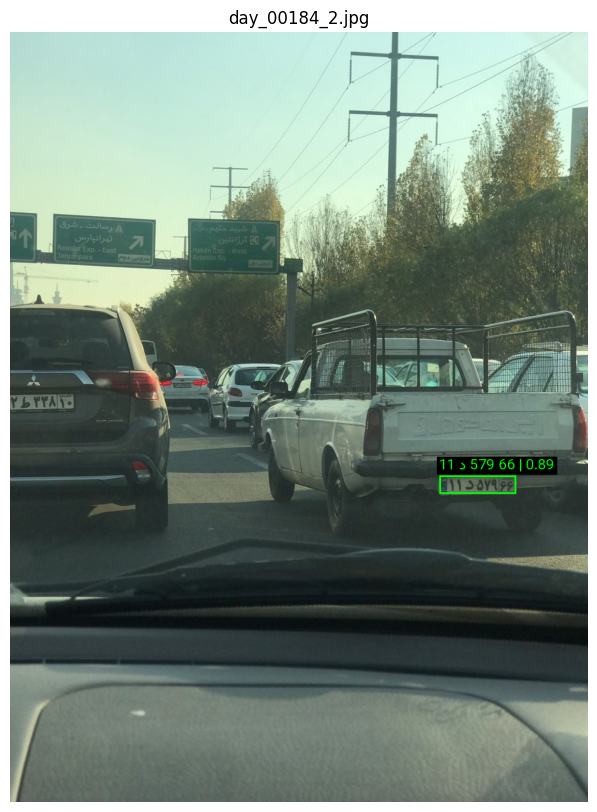

Saved visualization: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved models/inference_outputs/images/day_00184_2_annotated.png
Saved report: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved models/inference_outputs/reports/day_00184_2_results.csv


In [23]:
print_boxed("Single Image Inference")

image_path_str = input("Enter image path: ").strip().strip("'\"")
image_path = Path(image_path_str).expanduser().resolve()

if not image_path.exists():
    raise FileNotFoundError(f"Image not found: {image_path}")

image = load_rgb_image(image_path)

results = run_pipeline_on_image(image, CFG)

df_results = image_results_to_dataframe(results)
display(df_results)

vis = visualize_image_results(image, results, CFG)

plt.figure(figsize=(16, 10))
plt.imshow(vis)
plt.axis("off")
plt.title(image_path.name)
plt.show()

if CFG.save_visualizations:
    out_img = OUTPUT_DIR / "images" / f"{image_path.stem}_annotated.png"
    vis.save(out_img)
    print("Saved visualization:", out_img)

report_csv = OUTPUT_DIR / "reports" / f"{image_path.stem}_results.csv"
df_results.to_csv(report_csv, index=False, encoding="utf-8-sig")
print("Saved report:", report_csv)

save_plate_and_char_crops(image_path.stem, results, CFG)

In [24]:
class PlateKalmanFilter:
    """
    8D constant-velocity Kalman filter:
    state = [cx, cy, w, h, vx, vy, vw, vh]
    measurement = [cx, cy, w, h]
    """

    def __init__(
        self,
        bbox: Tuple[int, int, int, int],
        process_noise: float,
        measurement_noise: float,
    ) -> None:
        cx, cy = bbox_center_xyxy(bbox)
        w, h = bbox_wh_xyxy(bbox)

        self.x = np.array([cx, cy, w, h, 0.0, 0.0, 0.0, 0.0], dtype=np.float32)
        self.P = np.eye(8, dtype=np.float32) * 10.0

        self.Q = np.eye(8, dtype=np.float32) * float(process_noise)
        self.R = np.eye(4, dtype=np.float32) * float(measurement_noise)

        self.F = np.eye(8, dtype=np.float32)
        self.F[0, 4] = 1.0
        self.F[1, 5] = 1.0
        self.F[2, 6] = 1.0
        self.F[3, 7] = 1.0

        self.H = np.zeros((4, 8), dtype=np.float32)
        self.H[0, 0] = 1.0
        self.H[1, 1] = 1.0
        self.H[2, 2] = 1.0
        self.H[3, 3] = 1.0

    @staticmethod
    def bbox_to_measurement(bbox: Tuple[int, int, int, int]) -> np.ndarray:
        cx, cy = bbox_center_xyxy(bbox)
        w, h = bbox_wh_xyxy(bbox)
        return np.array([cx, cy, w, h], dtype=np.float32)

    @staticmethod
    def state_to_bbox(x: np.ndarray) -> Tuple[int, int, int, int]:
        cx, cy, w, h = float(x[0]), float(x[1]), float(x[2]), float(x[3])
        w = max(2.0, w)
        h = max(2.0, h)

        x1 = int(round(cx - w / 2.0))
        y1 = int(round(cy - h / 2.0))
        x2 = int(round(cx + w / 2.0))
        y2 = int(round(cy + h / 2.0))

        return x1, y1, x2, y2

    def predict(self) -> Tuple[int, int, int, int]:
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q
        return self.state_to_bbox(self.x)

    def update(self, bbox: Tuple[int, int, int, int]) -> Tuple[int, int, int, int]:
        z = self.bbox_to_measurement(bbox)

        y = z - (self.H @ self.x)
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)

        self.x = self.x + K @ y
        I = np.eye(8, dtype=np.float32)
        self.P = (I - K @ self.H) @ self.P

        return self.state_to_bbox(self.x)

    def innovation_distance(self, bbox: Tuple[int, int, int, int]) -> float:
        z = self.bbox_to_measurement(bbox)
        y = z - (self.H @ self.x)
        S = self.H @ self.P @ self.H.T + self.R

        try:
            d = float(y.T @ np.linalg.inv(S) @ y)
        except Exception:
            d = 1e9

        return d


@dataclass
class TrackState:
    track_id: int
    bbox: Tuple[int, int, int, int]
    last_frame_index: int
    missing_frames: int

    best_result: Optional[PlateOCRResult]
    best_confidence: float
    last_ocr_frame: int

    hits: int
    age: int
    confirmed: bool

    velocity: Tuple[float, float]
    bbox_history: List[Tuple[int, int, int, int]]
    ocr_history: List[Tuple[str, float]]

    feature: Optional[np.ndarray]
    feature_history_count: int

    predicted_bbox: Tuple[int, int, int, int]
    kf: PlateKalmanFilter

    def predict_once(self) -> Tuple[int, int, int, int]:
        self.predicted_bbox = self.kf.predict()
        return self.predicted_bbox

    def update_motion(
        self,
        det_bbox: Tuple[int, int, int, int],
        history_size: int,
        smooth_alpha: float,
    ) -> None:
        old_cx, old_cy = bbox_center_xyxy(self.bbox)

        kalman_bbox = self.kf.update(det_bbox)
        self.bbox = smooth_bbox_xyxy(self.bbox, kalman_bbox, smooth_alpha)
        self.predicted_bbox = self.bbox

        new_cx, new_cy = bbox_center_xyxy(self.bbox)
        self.velocity = (new_cx - old_cx, new_cy - old_cy)

        self.bbox_history.append(self.bbox)
        if len(self.bbox_history) > history_size:
            self.bbox_history = self.bbox_history[-history_size:]

    def mark_missed(self) -> None:
        self.missing_frames += 1
        self.bbox = self.predicted_bbox
        self.bbox_history.append(self.bbox)

    def add_ocr_result(self, result: PlateOCRResult, keep_top_k: int) -> None:
        if result.accepted and result.normalized_text.strip():
            self.ocr_history.append((result.normalized_text, result.final_confidence))
            self.ocr_history = sorted(
                self.ocr_history,
                key=lambda x: x[1],
                reverse=True,
            )[:keep_top_k]

    def update_feature(self, new_feature: Optional[np.ndarray], alpha: float) -> None:
        if new_feature is None:
            return

        new_feature = new_feature.astype(np.float32)
        new_feature = new_feature / (np.linalg.norm(new_feature) + 1e-12)

        if self.feature is None:
            self.feature = new_feature
            self.feature_history_count = 1
            return

        fused = alpha * self.feature + (1.0 - alpha) * new_feature
        self.feature = (fused / (np.linalg.norm(fused) + 1e-12)).astype(np.float32)
        self.feature_history_count += 1

    def get_consensus_text(self, min_count: int = 2) -> Tuple[str, float]:
        if not self.ocr_history:
            return "", 0.0

        grouped = defaultdict(list)
        for text, conf in self.ocr_history:
            grouped[text].append(conf)

        ranked = []
        for text, confs in grouped.items():
            count = len(confs)
            mean_conf = float(np.mean(confs))
            max_conf = float(np.max(confs))
            score = count * 0.70 + mean_conf * 0.20 + max_conf * 0.10
            ranked.append((text, score, count, mean_conf, max_conf))

        ranked.sort(key=lambda x: x[1], reverse=True)
        best_text, _, count, mean_conf, max_conf = ranked[0]

        if count < min_count:
            best_text, best_conf = max(self.ocr_history, key=lambda x: x[1])
            return best_text, best_conf

        return best_text, max_conf


class AdvancedPlateTracker:
    def __init__(self, cfg: InferenceConfig) -> None:
        self.cfg = cfg
        self.next_track_id = 1
        self.tracks: Dict[int, TrackState] = {}

    def _create_track(
        self,
        det: PlateDetection,
        frame_index: int,
        feature: Optional[np.ndarray],
    ) -> int:
        track_id = self.next_track_id
        self.next_track_id += 1

        kf = PlateKalmanFilter(
            det.bbox,
            process_noise=self.cfg.tracking_kalman_process_noise,
            measurement_noise=self.cfg.tracking_kalman_measurement_noise,
        )

        self.tracks[track_id] = TrackState(
            track_id=track_id,
            bbox=det.bbox,
            last_frame_index=frame_index,
            missing_frames=0,
            best_result=None,
            best_confidence=0.0,
            last_ocr_frame=-10**9,
            hits=1,
            age=1,
            confirmed=False,
            velocity=(0.0, 0.0),
            bbox_history=[det.bbox],
            ocr_history=[],
            feature=feature,
            feature_history_count=1 if feature is not None else 0,
            predicted_bbox=det.bbox,
            kf=kf,
        )
        return track_id

    def _gate_match(
        self,
        track: TrackState,
        det: PlateDetection,
        det_feature: Optional[np.ndarray],
    ) -> bool:
        pred_bbox = track.predicted_bbox

        iou = bbox_iou_xyxy(pred_bbox, det.bbox)
        c_score = center_distance_score(
            pred_bbox,
            det.bbox,
            max_ratio=self.cfg.tracking_max_center_distance_ratio,
        )
        s_score = size_similarity_score(pred_bbox, det.bbox)

        app_score = 0.0
        if self.cfg.tracking_use_appearance:
            app_score = max(0.0, cosine_similarity_np(track.feature, det_feature))

        if s_score < self.cfg.tracking_gate_min_size_similarity:
            return False

        motion_ok = (
            iou >= self.cfg.tracking_gate_min_iou
            or c_score >= self.cfg.tracking_gate_min_center_score
        )

        appearance_ok = (
            self.cfg.tracking_use_appearance
            and track.feature is not None
            and det_feature is not None
            and app_score >= self.cfg.tracking_feature_similarity_threshold
        )

        if not motion_ok and not appearance_ok:
            return False

        return True

    def _compute_match_score(
        self,
        track: TrackState,
        det: PlateDetection,
        det_feature: Optional[np.ndarray],
        det_ocr_hint: str = "",
    ) -> float:

        # gate check
        if not self._gate_match(track, det, det_feature):
            return -1.0

        pred_bbox = track.predicted_bbox

        # geometric scores
        iou_score = bbox_iou_xyxy(pred_bbox, det.bbox)

        c_score = center_distance_score(
            pred_bbox,
            det.bbox,
            max_ratio=self.cfg.tracking_max_center_distance_ratio,
        )

        s_score = size_similarity_score(
            pred_bbox,
            det.bbox,
        )

        # detection confidence
        d_score = float(np.clip(det.confidence, 0.0, 1.0))

        # appearance score
        appearance_score = 0.0
        if self.cfg.tracking_use_appearance:
            appearance_score = max(
                0.0,
                cosine_similarity_np(track.feature, det_feature)
            )

        # OCR score
        consensus_text, _ = track.get_consensus_text(
            min_count=self.cfg.tracking_ocr_vote_min_count
        )

        ocr_score = 0.0

        if consensus_text and det_ocr_hint:

            ocr_score = ocr_text_similarity(consensus_text, det_ocr_hint)

            # exact match → maximum score
            if consensus_text == det_ocr_hint:
                ocr_score = 1.0

            # strong mismatch → forbid match (prevents ID switch)
            if ocr_score < 0.3:
                return -1.0

        # normalize weights
        w_iou = self.cfg.tracking_iou_weight
        w_center = self.cfg.tracking_center_weight
        w_size = self.cfg.tracking_size_weight
        w_det = self.cfg.tracking_detection_conf_weight
        w_app = self.cfg.tracking_appearance_weight if self.cfg.tracking_use_appearance else 0.0
        w_ocr = self.cfg.tracking_ocr_weight

        total_w = max(w_iou + w_center + w_size + w_det + w_app + w_ocr, 1e-8)

        score = (
            w_iou * iou_score +
            w_center * c_score +
            w_size * s_score +
            w_det * d_score +
            w_app * appearance_score +
            w_ocr * ocr_score
        ) / total_w

        return float(score)

    def _associate(
        self,
        candidate_track_ids: List[int],
        detections: List[PlateDetection],
        det_features: List[Optional[np.ndarray]],
        det_ocr_hints: List[str],
    ) -> Tuple[Dict[int, int], List[int], List[int]]:
        matches: Dict[int, int] = {}

        if len(candidate_track_ids) == 0 or len(detections) == 0:
            return matches, candidate_track_ids[:], list(range(len(detections)))

        cost = np.ones((len(candidate_track_ids), len(detections)), dtype=np.float32) * 1e6

        for i, track_id in enumerate(candidate_track_ids):
            track = self.tracks[track_id]
            for j, det in enumerate(detections):
                score = self._compute_match_score(
                    track=track,
                    det=det,
                    det_feature=det_features[j],
                    det_ocr_hint=det_ocr_hints[j],
                )
                if score >= self.cfg.tracking_min_match_score:
                    cost[i, j] = 1.0 - score

        row_ind, col_ind = linear_sum_assignment(cost)

        matched_tracks = set()
        matched_dets = set()

        for r, c in zip(row_ind, col_ind):
            if cost[r, c] >= 1e5:
                continue

            track_id = candidate_track_ids[r]
            matches[track_id] = c
            matched_tracks.add(track_id)
            matched_dets.add(c)

        unmatched_tracks = [tid for tid in candidate_track_ids if tid not in matched_tracks]
        unmatched_dets = [j for j in range(len(detections)) if j not in matched_dets]

        return matches, unmatched_tracks, unmatched_dets

    def _apply_match(
        self,
        track_id: int,
        det: PlateDetection,
        feat: Optional[np.ndarray],
        frame_index: int,
    ) -> None:
        track = self.tracks[track_id]

        track.update_motion(
            det.bbox,
            history_size=self.cfg.tracking_history_size,
            smooth_alpha=self.cfg.tracking_smooth_bbox_alpha,
        )
        track.update_feature(feat, self.cfg.tracking_feature_ema_alpha)

        track.last_frame_index = frame_index
        track.missing_frames = 0
        track.hits += 1

        if (not track.confirmed) and track.hits >= self.cfg.tracking_confirmed_hits:
            track.confirmed = True

    def update(
        self,
        detections: List[PlateDetection],
        frame_index: int,
        frame_image: Image.Image,
    ) -> Dict[int, PlateDetection]:

        assignments: Dict[int, PlateDetection] = {}

        for track in self.tracks.values():
            track.age += 1
            track.predict_once()

        # -------------------------------------------------
        # Build aligned per-detection feature/OCR arrays
        # EXACTLY one entry per detection, no matter what happens
        # -------------------------------------------------
        det_features: List[Optional[np.ndarray]] = [None] * len(detections)
        det_ocr_hints: List[str] = [""] * len(detections)

        for det_idx, det in enumerate(detections):
            feat = None
            ocr_hint = ""
            crop = None

            try:
                if (
                    self.cfg.tracking_use_appearance
                    or det.confidence >= self.cfg.tracking_high_conf_det_threshold
                ):
                    crop = crop_plate_from_bbox(
                        frame_image,
                        det.bbox,
                        self.cfg.tracking_reid_crop_pad_x,
                        self.cfg.tracking_reid_crop_pad_y,
                    )
            except Exception:
                crop = None

            if crop is not None:
                if self.cfg.tracking_use_appearance:
                    try:
                        feat = extract_plate_feature(crop)
                    except Exception:
                        feat = None

                if det.confidence >= self.cfg.tracking_high_conf_det_threshold:
                    try:
                        ocr_result = run_ocr_on_plate_crop(crop, self.cfg)

                        if (
                            ocr_result is not None
                            and ocr_result.accepted
                            and ocr_result.normalized_text is not None
                            and len(ocr_result.normalized_text.strip()) >= 4
                        ):
                            ocr_hint = ocr_result.normalized_text.strip()
                    except Exception:
                        ocr_hint = ""

            det_features[det_idx] = feat
            det_ocr_hints[det_idx] = ocr_hint

        # Hard safety checks
        assert len(det_features) == len(detections), (
            f"det_features mismatch: {len(det_features)} vs detections {len(detections)}"
        )
        assert len(det_ocr_hints) == len(detections), (
            f"det_ocr_hints mismatch: {len(det_ocr_hints)} vs detections {len(detections)}"
        )

        confirmed_track_ids = [
            tid for tid, t in self.tracks.items()
            if t.confirmed
        ]

        tentative_track_ids = [
            tid for tid, t in self.tracks.items()
            if not t.confirmed
        ]

        high_conf_indices = [
            i for i, d in enumerate(detections)
            if d.confidence >= self.cfg.tracking_high_conf_det_threshold
        ]

        low_conf_indices = [
            i for i, d in enumerate(detections)
            if (
                self.cfg.tracking_low_conf_det_threshold
                <= d.confidence
                < self.cfg.tracking_high_conf_det_threshold
            )
        ]

        high_dets = [detections[i] for i in high_conf_indices]
        high_feats = [det_features[i] for i in high_conf_indices]
        high_ocr = [det_ocr_hints[i] for i in high_conf_indices]

        low_dets = [detections[i] for i in low_conf_indices]
        low_feats = [det_features[i] for i in low_conf_indices]
        low_ocr = [det_ocr_hints[i] for i in low_conf_indices]

        used_det_global = set()

        matches1, unmatched_confirmed, unmatched_high = self._associate(
            confirmed_track_ids,
            high_dets,
            high_feats,
            high_ocr,
        )

        for track_id, local_det_idx in matches1.items():
            global_det_idx = high_conf_indices[local_det_idx]

            self._apply_match(
                track_id,
                detections[global_det_idx],
                det_features[global_det_idx],
                frame_index,
            )

            assignments[track_id] = detections[global_det_idx]
            used_det_global.add(global_det_idx)

        rem_high_indices = [
            high_conf_indices[i]
            for i in unmatched_high
        ]

        rem_high_dets = [detections[i] for i in rem_high_indices]
        rem_high_feats = [det_features[i] for i in rem_high_indices]
        rem_high_ocr = [det_ocr_hints[i] for i in rem_high_indices]

        matches2, unmatched_tentative, unmatched_high2 = self._associate(
            tentative_track_ids,
            rem_high_dets,
            rem_high_feats,
            rem_high_ocr,
        )

        for track_id, local_det_idx in matches2.items():
            global_det_idx = rem_high_indices[local_det_idx]

            self._apply_match(
                track_id,
                detections[global_det_idx],
                det_features[global_det_idx],
                frame_index,
            )

            assignments[track_id] = detections[global_det_idx]
            used_det_global.add(global_det_idx)

        unmatched_after_high = unmatched_confirmed + unmatched_tentative

        matches3, still_unmatched_tracks, unmatched_low = self._associate(
            unmatched_after_high,
            low_dets,
            low_feats,
            low_ocr,
        )

        for track_id, local_det_idx in matches3.items():
            global_det_idx = low_conf_indices[local_det_idx]

            self._apply_match(
                track_id,
                detections[global_det_idx],
                det_features[global_det_idx],
                frame_index,
            )

            assignments[track_id] = detections[global_det_idx]
            used_det_global.add(global_det_idx)

        matched_track_ids = set(assignments.keys())

        for track_id, track in list(self.tracks.items()):
            if track_id not in matched_track_ids:
                track.mark_missed()

        unmatched_new_det_indices = [
            i for i in high_conf_indices
            if i not in used_det_global
        ]

        for det_idx in unmatched_new_det_indices:
            det = detections[det_idx]
            feat = det_features[det_idx]

            new_track_id = self._create_track(
                det=det,
                frame_index=frame_index,
                feature=feat,
            )

            assignments[new_track_id] = det

        to_delete = []

        for track_id, track in self.tracks.items():
            max_age = (
                self.cfg.tracking_tentative_max_age
                if not track.confirmed
                else self.cfg.tracking_max_missing_frames
            )

            if track.missing_frames > max_age:
                to_delete.append(track_id)

        for track_id in to_delete:
            del self.tracks[track_id]

        return assignments

In [25]:
def draw_video_tracks(
    image: Image.Image,
    tracker: AdvancedPlateTracker,
    cfg: InferenceConfig,
) -> Image.Image:
    vis = image.copy()
    draw = ImageDraw.Draw(vis)

    for track_id, track in tracker.tracks.items():
        if not track.confirmed and track.hits < 2:
            continue

        x1, y1, x2, y2 = track.bbox

        consensus_text, consensus_conf = track.get_consensus_text(
            min_count=cfg.tracking_ocr_vote_min_count
        )

        if track.best_result is not None and track.best_result.accepted:
            color = "lime"
            shown_text = consensus_text.strip() if consensus_text.strip() else track.best_result.formatted_text
            text = f"ID {track_id} | {shown_text} | {max(consensus_conf, track.best_confidence):.2f}"
        else:
            color = "yellow"
            text = f"ID {track_id} | tracking"

        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)

        draw_text_with_background(
            draw=draw,
            position=(x1, max(0, y1 - 35)),
            text=text,
            font=VIDEO_TEXT_FONT,
            text_fill=color,
            bg_fill="black",
            padding=4,
        )

    return vis

In [26]:
def run_video_inference(
    video_path: Path,
    cfg: InferenceConfig,
) -> pd.DataFrame:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps is None or fps <= 0 or not np.isfinite(fps):
        fps = 25.0

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    output_fps = cfg.video_output_fps if cfg.video_output_fps is not None else fps

    video_out_path = OUTPUT_DIR / "videos" / f"{video_path.stem}_annotated.mp4"
    writer = None

    if cfg.save_visualizations:
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(
            str(video_out_path),
            fourcc,
            output_fps,
            (width, height),
        )

    tracker = AdvancedPlateTracker(cfg)

    rows = []
    frame_index = 0
    processed_frames = 0

    pbar = tqdm(total=total_frames if total_frames > 0 else None, desc="Video inference")

    try:
        while True:
            ok, frame_bgr = cap.read()
            if not ok:
                break

            if cfg.video_max_frames is not None and processed_frames >= cfg.video_max_frames:
                break

            if frame_index % cfg.video_frame_stride != 0:
                frame_index += 1
                pbar.update(1)
                continue

            frame_image = bgr_np_to_pil(frame_bgr)

            try:
                plate_detections = run_model1(frame_image, cfg)
            except Exception:
                plate_detections = []

            assignments = tracker.update(
                detections=plate_detections,
                frame_index=frame_index,
                frame_image=frame_image,
            )

            for track_id, det in assignments.items():
                track = tracker.tracks.get(track_id)
                if track is None:
                    continue

                should_run_ocr = (
                    track.best_result is None
                    or (frame_index - track.last_ocr_frame) >= cfg.tracking_min_ocr_interval_frames
                    or (cfg.tracking_ocr_force_rerun_if_unread and (track.best_result is None or not track.best_result.accepted))
                )

                current_ocr_result = None

                if should_run_ocr:
                    try:
                        plate_crop = crop_plate(frame_image, det, cfg)
                        ocr_result, _ = run_ocr_on_plate_crop(plate_crop, det, cfg)
                        track.last_ocr_frame = frame_index
                        current_ocr_result = ocr_result

                        if ocr_result.accepted:
                            track.add_ocr_result(
                                ocr_result,
                                keep_top_k=cfg.tracking_ocr_keep_top_k,
                            )

                            improved = (
                                track.best_result is None
                                or ocr_result.final_confidence > track.best_confidence + cfg.tracking_min_conf_improvement
                            )

                            if improved:
                                track.best_result = ocr_result
                                track.best_confidence = ocr_result.final_confidence
                    except Exception:
                        pass

                consensus_text, consensus_conf = track.get_consensus_text(
                    min_count=cfg.tracking_ocr_vote_min_count
                )

                best = track.best_result

                tx1, ty1, tx2, ty2 = track.bbox

                rows.append({
                    "frame_index": frame_index,
                    "track_id": track_id,
                    "confirmed": track.confirmed,
                    "hits": track.hits,
                    "missing_frames": track.missing_frames,
                    "xmin": det.xmin,
                    "ymin": det.ymin,
                    "xmax": det.xmax,
                    "ymax": det.ymax,
                    "det_confidence": det.confidence,
                    "current_ocr_accepted": current_ocr_result.accepted if current_ocr_result is not None else False,
                    "current_ocr_text": current_ocr_result.normalized_text if current_ocr_result is not None else "",
                    "has_best_result": best is not None,
                    "accepted": best.accepted if best is not None else False,
                    "best_normalized_text": best.normalized_text if best is not None else "",
                    "best_formatted_text": best.formatted_text if best is not None else "",
                    "best_final_confidence": best.final_confidence if best is not None else 0.0,
                    "consensus_text": consensus_text,
                    "consensus_confidence": consensus_conf,
                })

            if writer is not None:
                vis = draw_video_tracks(frame_image, tracker, cfg)
                writer.write(pil_to_bgr_np(vis))

            frame_index += 1
            processed_frames += 1
            pbar.update(1)

    finally:
        pbar.close()
        cap.release()
        if writer is not None:
            writer.release()

    df = pd.DataFrame(rows)
    return df

In [27]:
print_boxed("Video Inference")

video_path_str = input("Enter video path: ").strip("'\"")
video_path = Path(video_path_str).expanduser().resolve()

if not video_path.exists():
    raise FileNotFoundError(f"Video not found: {video_path}")

video_df = run_video_inference(video_path, CFG)

display(video_df.head(30))

video_report_csv = OUTPUT_DIR / "reports" / f"{video_path.stem}_video_results.csv"
video_df.to_csv(video_report_csv, index=False, encoding="utf-8-sig")
print("Saved video report:", video_report_csv)

if len(video_df) > 0:
    summary_df = (
        video_df.sort_values("best_final_confidence", ascending=False)
        .drop_duplicates(subset=["track_id"])
        .sort_values("track_id")
        .reset_index(drop=True)
    )

    summary_csv = OUTPUT_DIR / "reports" / f"{video_path.stem}_track_summary.csv"
    summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")

    print("Saved track summary:", summary_csv)
    display(summary_df)


Video Inference


Video inference:   0%|          | 0/356 [00:00<?, ?it/s]

,frame_index,track_id,confirmed,hits,missing_frames,xmin,ymin,xmax,ymax,det_confidence,current_ocr_accepted,current_ocr_text,has_best_result,accepted,best_normalized_text,best_formatted_text,best_final_confidence,consensus_text,consensus_confidence
0,0,1,False,1,0,1717,851,2435,1101,0.904857,True,29ی12144,True,True,29ی12144,29 ی 121 44,0.890335,29ی12144,0.890335
1,1,1,False,2,0,1717,853,2435,1097,0.902168,False,,True,True,29ی12144,29 ی 121 44,0.890335,29ی12144,0.890335
2,2,1,True,3,0,1721,852,2443,1098,0.900215,False,,True,True,29ی12144,29 ی 121 44,0.890335,29ی12144,0.890335
3,3,1,True,4,0,1723,850,2446,1098,0.900402,False,,True,True,29ی12144,29 ی 121 44,0.890335,29ی12144,0.890335
4,4,1,True,5,0,1724,850,2450,1099,0.899784,False,,True,True,29ی12144,29 ی 121 44,0.890335,29ی12144,0.890335
5,5,1,True,6,0,1725,847,2452,1099,0.898955,False,,True,True,29ی12144,29 ی 121 44,0.890335,29ی12144,0.890335
6,6,1,True,7,0,1726,846,2455,1103,0.897398,False,,True,True,29ی12144,29 ی 121 44,0.890335,29ی12144,0.890335
7,7,1,True,8,0,1729,847,2455,1100,0.897026,False,,True,True,29ی12144,29 ی 121 44,0.890335,29ی12144,0.890335
8,8,1,True,9,0,1732,848,2454,1100,0.896051,False,,True,True,29ی12144,29 ی 121 44,0.890335,29ی12144,0.890335
9,9,1,True,10,0,1730,847,2456,1092,0.900110,False,,True,True,29ی12144,29 ی 121 44,0.890335,29ی12144,0.890335


Saved video report: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved models/inference_outputs/reports/IMG_8250_video_results.csv
Saved track summary: /Users/sam/Desktop/aiolearn/My_projects/CLPR/Saved models/inference_outputs/reports/IMG_8250_track_summary.csv


,frame_index,track_id,confirmed,hits,missing_frames,xmin,ymin,xmax,ymax,det_confidence,current_ocr_accepted,current_ocr_text,has_best_result,accepted,best_normalized_text,best_formatted_text,best_final_confidence,consensus_text,consensus_confidence
0,0,1,False,1,0,1717,851,2435,1101,0.904857,True,29ی12144,True,True,29ی12144,29 ی 121 44,0.890335,29ی12144,0.890335
1,209,2,False,2,0,1430,904,2279,1105,0.615729,False,,True,True,29ی12144,29 ی 121 44,0.791553,29ی12144,0.791553
